# About the project

This notebook analyses the People and Companies dataset, associated with collections of the Science Museum Group:
https://collection.sciencemuseumgroup.org.uk/

Contents
1. Descriptive statistics
2. Extracting activity dates and other dates from 'Biographies'
3. What 'companies' are in the People and Companies dataset? AI classification

In [28]:
import pandas as pd
import numpy as np
from datetime import datetime
import re

### Data

In [2]:
# Json with People&Companies dataset might be found here:
# https://coimages.sciencemuseumgroup.org.uk/datasets/index.html
# This Json must be flattened for analysis using this code: https://colab.research.google.com/drive/1cDP5a7VIrZVlJ9e_X9f4_gv_ZRreEvCD
# I'm using the resulting excel - smg_people_and_company_indexed_120825_fin.xlsx

people_onl = pd.read_excel(r'/Users/Lusia/Library/CloudStorage/Dropbox/PhD/Placement/datasets/smg_people_and_company_indexed_120825_fin.xlsx')

# As this dataset includes people from two potentially duplicating datasets, people in collections and people in archives, we're going to focus only on one: collections
# To indicate only collections, we take only those records, where in '@admin.uid' the first two letters are 'cp' = collections
people_onl = people_onl[people_onl['@admin.uid'].str.contains('cp')].reset_index(drop=True)

## Part 1. Descriptive statistics

### 1.1. Persons & Companies 

In [12]:
# How many individuals and companies are in this dataset, approximately?
people_onl['@datatype.actual'].value_counts(normalize=True)

@datatype.actual
person          0.5502
organisation    0.4498
Name: proportion, dtype: float64

### 1.2. Periods

In [25]:
# Flattening Json
people_onl['BIRTH_DATE'] = pd.Series([np.nan] * len(people_onl), dtype=object)
people_onl.loc[(people_onl['date[0].role[0].value'] == 'date of birth'), 'BIRTH_DATE'] = people_onl['date[0].value']
people_onl.loc[((people_onl['date[1].role[0].value'] == 'date of birth') & (people_onl['BIRTH_DATE'].isna())), 'BIRTH_DATE'] = people_onl['date[1].value']
people_onl.loc[((~ people_onl['birth.date.value'].isna()) & (people_onl['BIRTH_DATE'].isna())), 'BIRTH_DATE'] = people_onl['birth.date.value']

people_onl['DEATH_DATE'] = pd.Series([np.nan] * len(people_onl), dtype=object)
people_onl.loc[(people_onl['date[0].role[0].value'] == 'date of death'), 'DEATH_DATE'] = people_onl['date[0].value']
people_onl.loc[((people_onl['date[1].role[0].value'] == 'date of death') & (people_onl['DEATH_DATE'].isna())), 'DEATH_DATE'] = people_onl['date[1].value']
people_onl.loc[((people_onl['date[2].role[0].value'] == 'date of death') & (people_onl['DEATH_DATE'].isna())), 'DEATH_DATE'] = people_onl['date[2].value']
people_onl.loc[((~ people_onl['death.date.value'].isna()) & (people_onl['DEATH_DATE'].isna())), 'DEATH_DATE'] = people_onl['death.date.value']

In [31]:
def convert_to_pandas_dates(series):
    """
    Convert various date formats to pandas datetime objects.
    
    Handles:
    - Full dates (YYYY-MM-DD)
    - Years only (YYYY) 
    - Approximate dates (c1815, ca1815, ~1815, c.1815)
    - Invalid/missing values
    
    Args:
        series: pandas Series containing date strings/values
        
    Returns:
        pandas Series with datetime objects
    """
    
    def parse_single_date(date_val):
        """Parse a single date value"""
        if pd.isna(date_val) or date_val == '':
            return pd.NaT
            
        # Convert to string and clean
        date_str = str(date_val).strip()
        
        # Handle approximate dates (remove c, ca, ~, circa prefixes)
        date_str = re.sub(r'^(c|ca|circa|~|c.)\s*', '', date_str, flags=re.IGNORECASE)
        
        try:
            # Try to parse as full date first
            if re.match(r'^\d{4}-\d{2}-\d{2}$', date_str):
                return pd.to_datetime(date_str)
            
            # Try to parse as year only
            elif re.match(r'^\d{4}$', date_str):
                year = int(date_str)
                # Set to January 1st of that year
                return pd.to_datetime(f'{year}-01-01')
            
            # Try other common formats
            else:
                # Let pandas try to parse it
                return pd.to_datetime(date_str, errors='coerce')
                
        except (ValueError, TypeError):
            return pd.NaT
    
    # Apply the parsing function to each element
    result = series.apply(parse_single_date)
    
    return result

# Comverting
if __name__ == "__main__":
    
    # Convert to pandas dates
    people_onl['BIRTH_DATE_dtm'] = convert_to_pandas_dates(people_onl['BIRTH_DATE'])
    people_onl['DEATH_DATE_dtm'] = convert_to_pandas_dates(people_onl['DEATH_DATE'])

# Single date for each person
people_onl['BIRTH_or_DEATH_year'] = np.nan
people_onl.loc[(~ people_onl['BIRTH_DATE_dtm'].isna()), 'BIRTH_or_DEATH_year'] = people_onl['BIRTH_DATE_dtm'].dt.year
people_onl.loc[((~ people_onl['DEATH_DATE_dtm'].isna()) & (people_onl['BIRTH_DATE_dtm'].isna())), 'BIRTH_or_DEATH_year'] = people_onl['DEATH_DATE_dtm'].dt.year

print('Percentage of cases where at least one date is published online: ', (len(people_onl[(~ people_onl['BIRTH_DATE'].isna()) | ((~ people_onl['DEATH_DATE'].isna()))]) / len(people_onl)) * 100)
print('Percentage of cases where date was succesfully extracted in datetime format:', (len(people_onl[~ people_onl['BIRTH_or_DEATH_year'].isna()]) / len(people_onl)) * 100)

/var/folders/06/9fn1s9_s4_j4jsl0jvwv2pkc0000gn/T/ipykernel_39228/3469980118.py:43: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  return pd.to_datetime(date_str, errors='coerce')
/var/folders/06/9fn1s9_s4_j4jsl0jvwv2pkc0000gn/T/ipykernel_39228/3469980118.py:43: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  return pd.to_datetime(date_str, errors='coerce')
/var/folders/06/9fn1s9_s4_j4jsl0jvwv2pkc0000gn/T/ipykernel_39228/3469980118.py:43: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  return pd.to_datetime(date_str, errors='coerce')


Percentage of cases where at least one date is published online:  49.605658487731596
Percentage of cases where date was succesfully extracted in datetime format: 47.32724086129193


In [33]:
# create larger groups for easier analysis and visualisation

bins = list(range(1650, 2100, 50))  # [1650, 1700, 1750, ..., 2000]
labels = [f"{start}-{start+49}" for start in bins[:-1]]  # One fewer label than bins

# Assign each year to a period
people_onl['Period'] = pd.cut(people_onl['BIRTH_or_DEATH_year'], 
                             bins=bins, 
                             labels=labels, 
                             include_lowest=True,
                             right=False)

# Count occurrences in each period
period_counts_people_onl = people_onl['Period'][people_onl['@datatype.actual'] == 'person'].value_counts().sort_index()
period_counts_companies_onl = people_onl['Period'][people_onl['@datatype.actual'] == 'organisation'].value_counts().sort_index()

datasets = {
    "people_onl": period_counts_people_onl,
    "companies_onl": period_counts_companies_onl
}

periods_table = []

for name, data in datasets.items():
    df = pd.DataFrame(data)
    df = df.rename(columns={df.columns[0]: name})
    periods_table.append(df)

periods_table_fin = pd.concat(periods_table, axis=1, join="outer")

periods_table_fin

,people_onl,companies_onl
Period,,
1650-1699,112,6
1700-1749,404,31
1750-1799,814,91
1800-1849,1307,479
1850-1899,1236,1032
1900-1949,733,679
1950-1999,218,376
2000-2049,9,34


### 1.3. Nationalities

In [45]:
people_onl['NATIONALITY_list'] = people_onl['nationality[0]'].str.split(r';|,|\/|\&', regex=True)

british_group = {"English", "Scottish", "Welsh", "Northern irish"}
# Here, those who are 'Irish' and 'British' are counted as separate units.
# While "English", "Scottish", "Welsh", "Northern irish" are united in a group "British".
# This logic might be changed.

def normalize_row(row):
    if not isinstance(row, list):
        return None
    
    # Clean entries
    cleaned = [x.strip().capitalize().rstrip("?") for x in row]
    
    # If row contains any "British group"
    if any(x in british_group for x in cleaned):
        # Special case: Irish + British group → British
        return ["British"]
    else:
        return cleaned

# Apply normalization
people_onl['Nationality_normalized'] = people_onl['NATIONALITY_list'].apply(normalize_row)

# Flatten and count people
freqs_people = (
    people_onl['Nationality_normalized'][people_onl['@datatype.actual'] == 'person'].explode()
    .dropna()
    .value_counts()
)

# Flatten and count companies
freqs_companies = (
    people_onl['Nationality_normalized'][people_onl['@datatype.actual'] == 'organisation'].explode()
    .dropna()
    .value_counts()
)

freqs_people = pd.DataFrame(freqs_people).reset_index(drop=False)
freqs_people.columns = ['Nationality', 'People_Online']
freqs_companies = pd.DataFrame(freqs_companies).reset_index(drop=False)
freqs_companies.columns = ['Nationality', 'Companies_Online']

nationalities_demo = pd.merge(freqs_people, freqs_companies, on='Nationality', how='outer')

print('Percentage of NA for individuals: ', round((len(people_onl[(people_onl['nationality[0]'].isna()) & (people_onl['@datatype.actual'] == 'person')]) 
 / len(people_onl['@datatype.actual'] == 'person')) * 100), '%')

print('Percentage of NA for companies: ', round((len(people_onl[(people_onl['nationality[0]'].isna()) & (people_onl['@datatype.actual'] == 'organisation')]) 
 / len(people_onl['@datatype.actual'] == 'organisation')) * 100), '%')

Percentage of NA for individuals:  9 %
Percentage of NA for companies:  8 %


In [53]:
nationalities_demo = nationalities_demo.fillna(0).sort_values(by='People_Online', ascending=False)
# the most popular nationalities
print(nationalities_demo.head(20))

    Nationality  People_Online  Companies_Online
48      British         4712.0            4260.0
86       French          731.0             223.0
89       German          442.0             294.0
5      American          429.0             570.0
117     Italian          177.0              28.0
114       Irish          114.0              36.0
68        Dutch           95.0              23.0
38      Belgian           89.0              22.0
30     Austrian           86.0              19.0
182       Swiss           85.0              49.0
180     Swedish           71.0              27.0
165     Russian           40.0              12.0
107      Indian           32.0              30.0
106   Hungarian           32.0               0.0
176     Spanish           31.0              11.0
58     Canadian           30.0              27.0
100       Greek           30.0               1.0
25   Australian           27.0              14.0
67       Danish           23.0              12.0
66        Czech     

### 1.4 Gender

In [59]:
people_onl[people_onl['@datatype.actual'] == 'person']['gender.value'].value_counts(normalize=True)

gender.value
M    0.944483
F    0.055517
Name: proportion, dtype: float64

### 1.5 Occupations

In [60]:
from os import path
from PIL import Image
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
import matplotlib.pyplot as plt
stopwords = set(STOPWORDS)

In [66]:
# There are 3 occupation columns, join them into one

# List all occupation-related columns
occupation_cols = [
    'occupation.value',
    'occupation.value[0]',
    'occupation.value[1]'
]

# Fill NaN with empty string so we can safely join
people_onl[occupation_cols] = people_onl[occupation_cols].fillna('')

# Join all non-empty values with '; ' in each row
people_onl['OCCUPATION'] = people_onl[occupation_cols].apply(
    lambda x: '; '.join([v for v in x if v != '']),
    axis=1
)

In [75]:
print('Percentage of NAs for individuals in collections online: ', ((len(people_onl[(people_onl['OCCUPATION'] == '') & (people_onl['@datatype.actual'] == 'person')]) / len(people_onl[people_onl['@datatype.actual'] == 'person'])) * 100))
print('Percentage of NAs for companies in collections online: ', ((len(people_onl[(people_onl['OCCUPATION'] == '') & (people_onl['@datatype.actual'] == 'organisation')]) / len(people_onl[people_onl['@datatype.actual'] == 'organisation'])) * 100))

Percentage of NAs for individuals in collections online:  6.723549488054608
Percentage of NAs for companies in collections online:  8.293904814917896


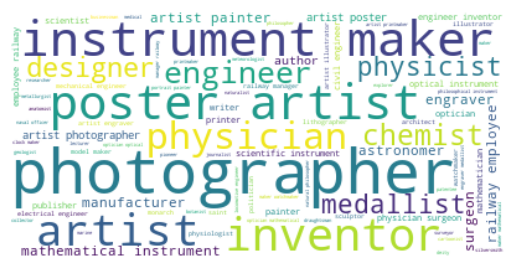

In [79]:
# WordCloud for individuals in published dataset
text = " ".join(map(str, list(people_onl['OCCUPATION'][(~ (people_onl['OCCUPATION'] == '')) & (people_onl['@datatype.actual'] == 'person')])))

# Create and generate a word cloud image:
wordcloud = WordCloud(max_font_size=50, max_words=100, background_color="white").generate(text)

# Display the generated image:
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

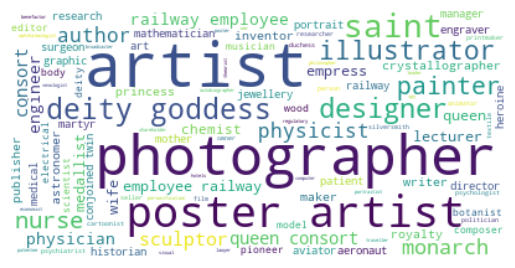

In [81]:
# WordCloud for FEMALE individuals in published dataset
text = " ".join(map(str, list(people_onl['OCCUPATION'][(~ (people_onl['OCCUPATION'] == '')) & 
    (people_onl['@datatype.actual'] == 'person') &
    (people_onl['gender.value'] == 'F')])))

# Create and generate a word cloud image:
wordcloud = WordCloud(max_font_size=50, max_words=100, background_color="white").generate(text)

# Display the generated image:
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

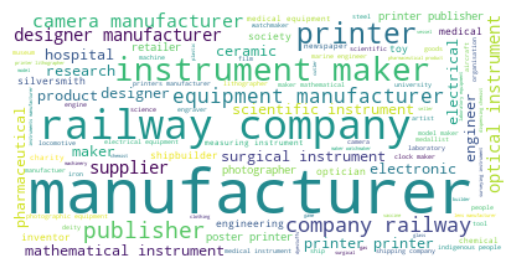

In [80]:
# WordCloud for companies in published dataset
text = " ".join(map(str, list(people_onl['OCCUPATION'][(~ (people_onl['OCCUPATION'] == '')) & (people_onl['@datatype.actual'] == 'organisation')])))

# Create and generate a word cloud image:
wordcloud = WordCloud(max_font_size=50, max_words=100, background_color="white").generate(text)

# Display the generated image:
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

## Part 2. Extracting activity dates and other dates from 'Biographies' 

In [86]:
# As only half of the entries have dates, the periodisation can be improved by adding 'Activity dates' from brief biographies.

# Example, how brief biographies look like:
print(people_onl[(people_onl['description[0].type'] == 'brief biography')]['description[0].value'].head(15))

0     Active 2007-, lottery operator and gaming tech...
1                      active 1885, physician, British?
2                        active 1837, lyricist, British
3                  active 1930s, poster artist, British
4                      active 1895, apothecary, British
5                       active 1950s, Goods Guard, York
6     1872-1900, steering gear and light marine engi...
7     active 1678, dean of faculty of medicine, Pari...
8             active 1772, artist; painter, Netherlands
9                                             physician
10                       active 1849, printer, Leighton
11                     active 1868, printer, Whitehaven
12                      Buddhist goddess, Tibet & Nepal
13                   active 1820, burger; regent, Dutch
14            active 1849-1854, burgomaster of Brussels
Name: description[0].value, dtype: object


In [89]:
people_onl['BRIEF_BIO'] = people_onl[(people_onl['description[0].type'] == 'brief biography')]['description[0].value']

### 2.1 Extracting dates using SpaCy

In [91]:
import spacy

# Load SpaCy English model
nlp = spacy.load("en_core_web_sm")

people_onl['BRIEF_BIO_updated'] = people_onl['BRIEF_BIO']
people_onl['BIRTH_DATE_updated'] = people_onl['BIRTH_DATE']
people_onl['DEATH_DATE_updated'] = people_onl['DEATH_DATE']

# preparation of dates before extraction

def clean_dates(text):
    if pd.isna(text):
        return text

    # h"1952-current (2009)" and spacing variants → "1952 -"
    text = re.sub(
        r'(\d{3,4})\s*-\s*current\s*\(\d{3,4}\)', 
        r'\1 -', 
        text, 
        flags=re.IGNORECASE
    )

    #  "b c1970" → "1970"
    text = re.sub(r'\bb\s*c?\.?(\d{3,4})', r'\1', text, flags=re.IGNORECASE)

    # "c.1970" or "c1970" → "1970"
    text = re.sub(r'c\.?\s*(\d{3,4})', r'\1', text, flags=re.IGNORECASE)

    #  "1836?-1909" → "1836-1909"
    text = re.sub(r'(\d{3,4})\?-(\d{3,4})', r'\1-\2', text)

    # "1906-1978?" → "1906-1978"
    text = re.sub(r'(\d{3,4})-(\d{3,4})\?', r'\1-\2', text)

    # 1760s-1920s, → 1760s-1920s
    text = re.sub(r'(\d{4}s-\d{4}s),', r'\1', text)
    
    # 1760s-1920s? → 1760s-1920s
    # 1760s-1920s?, → 1760s-1920s
    text = re.sub(r'(\d{4}s-\d{4}s)\?,?', r'\1', text)

    # 1830s-1840s -> 1830s - 1840s
    text = re.sub(r'(\d{4}s)\s*-\s*(\d{4}s)', r'\1 - \2', text)
      
    # "current (anything)" → "current"
    text = re.sub(r'current\s*\([^)]*\)', 'current', text, flags=re.IGNORECASE)

    # "1880s-1900," → "1880s - 1900"
    text = re.sub(r'(\d{4}s)-(\d{4}),', r'\1 - \2', text)

    # "1990-,", "1948- ,", "1973-, ", "1912-?," → "YYYY - current"
    text = re.sub(r'(\d{4})\s*-\s*\?,?', r'\1 - current', text)  # handles "1912-?,"
    text = re.sub(r'(\d{3,4})\s*-\s*(?:\?|,)?\s*$', r'\1 - current', text)   # handles "1990-," etc.
    

    # "1988- current" → "1988 - current"
    text = re.sub(r'(\d{4})\s*-\s*current', r'\1 - current', text, flags=re.IGNORECASE)

    return text


# Function to extract dates

def extract_dates(text):
    doc = nlp(text)
    results = []
    for ent in doc.ents:
        if ent.label_ == "DATE":
            # Check nearby words
            sentence = ent.sent.text.lower()
            if ("born" in sentence 
                or "birthday" in sentence 
                or "date of birth" in sentence 
                or re.search(r"(?:^| )b\s", sentence)
               ):
                results.append({
                    "birth_date": ent.text
                })
            if "active" in sentence:
                results.append({
                    "active_date": ent.text
                })
            if (
                "death" in sentence
                or re.search(r"d\.", sentence)
                or re.search(r"(?:^| )d\s", sentence)
                ):
                results.append({
                    "death_date": ent.text
                })
            else:
                results.append({
                    "unknown_date": ent.text
                })
    return results


def convert_to_python_dates(series):
    """
    Convert various date formats to Python datetime objects.
    Uses Python datetime which can handle dates from year 1 to 9999.
    
    Handles:
    - Full dates (YYYY-MM-DD)
    - Years only (YYYY) 
    - Approximate dates (c1815, ca1815, ~1815, c.1815)
    - Invalid/missing values
    
    Args:
        series: pandas Series containing date strings/values
        
    Returns:
        pandas Series with Python datetime objects
    """
        # Apply the parsing function to each element
    return series.apply(parse_single_date)

    
def parse_single_date(date_val):
    """Parse a single date value"""
    if pd.isna(date_val) or date_val == '':
        return None  # Use None instead of pd.NaT for Python datetime
        
    # Convert to string and clean
    date_str = str(date_val).strip()
    
    # Handle approximate dates (remove c, ca, ~, circa prefixes)
    date_str = re.sub(r'^(c|ca|circa|about\s|~|c.)\s*', '', date_str, flags=re.IGNORECASE)
    
    try:
        # Try to parse as full date first
        if re.match(r'^\d{4}-\d{2}-\d{2}$', date_str):
            year, month, day = map(int, date_str.split('-'))
            return datetime(year, month, day)
        
        # Try to parse as year only
        elif re.match(r'^\d{4}$', date_str):
            year = int(date_str)
            return datetime(year, 1, 1)  # Set to January 1st
        
        # Try other common date formats
        else:
            # Try various common formats
            for fmt in ['%Y/%m/%d', '%m/%d/%Y', '%d/%m/%Y', '%Y-%m', '%m-%Y']:
                try:
                    return datetime.strptime(date_str, fmt)
                except ValueError:
                    continue
            
            # If none worked, try to extract just the year
            year_match = re.search(r'\b(\d{4})\b', date_str)
            if year_match:
                year = int(year_match.group(1))
                return datetime(year, 1, 1)
            
            return None
            
    except (ValueError, TypeError, OverflowError):
        return None



In [92]:
# Prepare dataset
people_onl['BRIEF_BIO_updated'] = people_onl['BRIEF_BIO_updated'].apply(clean_dates)
people_onl['DEATH_DATE_updated'] = people_onl['DEATH_DATE_updated'].apply(clean_dates)
people_onl['BIRTH_DATE_updated'] = people_onl['BIRTH_DATE_updated'].apply(clean_dates)

# Apply to the column
people_onl['dates'] = people_onl['BRIEF_BIO_updated'][~ people_onl['BRIEF_BIO_updated'].isna()].apply(extract_dates)

# Exploding dates from SpaCy into different columns
# Keep original index
idx = people_onl.index  

# Step 1: explode (index will repeat for lists, but that's ok)
exploded = people_onl['dates'].explode()

# Step 2: normalize dictionaries
normalized = pd.json_normalize(exploded).set_index(exploded.index)

# Step 3: collapse back to one row per original record
dates_expanded = normalized.groupby(level=0).first()

# Step 4: join back (indexes now match exactly)
people_onl = people_onl.join(dates_expanded)

# Separating date ranges into separate columns and converting them to DateTime

columns_to_separate = ['active_date', 'birth_date', 'death_date', 'unknown_date']

for column_name in columns_to_separate:

    # Split the series, expand into separate columns
    split_dates = people_onl[column_name].str.split('-', expand=True)
    
    # Create the new columns
    people_onl[f'{column_name}_from'] = split_dates[0].str.strip()
    people_onl[f'{column_name}_to'] = split_dates[1].str.strip()
    
    people_onl.loc[people_onl[f'{column_name}_to'].isna(), f'{column_name}_to'] = people_onl[f'{column_name}_from']

    # manage entries where there are 's' in the end. In case of 'from' - just delete S. In case of 'To' - replace with 9.
    people_onl[f'{column_name}_from'] = people_onl[f'{column_name}_from'].str.replace(r'^(\d{4})s$', r'\1', regex=True)
    people_onl[f'{column_name}_to'] = people_onl[f'{column_name}_to'].str.replace(r'^(\d{3})\d{1}s$', r'\g<1>9', regex=True)

    # manage 'active' and 'current' in 'date_to'. Change them to 'None'
    people_onl.loc[(people_onl[f'{column_name}_to'].str.contains(r'active|current', regex=True, na=False)), f'{column_name}_to'] = pd.NaT

    # convert dates into DateTime format in new columns
    people_onl[f'{column_name}_from_dtm'] = convert_to_python_dates(people_onl[f'{column_name}_from'])
    people_onl[f'{column_name}_to_dtm'] = convert_to_python_dates(people_onl[f'{column_name}_to'])

In [96]:
# percentages of NAs

print('Percentage of entries with at least 1 date: ', (len(people_onl[(~ people_onl['active_date_from_dtm'].isna()) |
(~ people_onl['unknown_date_from_dtm'].isna()) |
(~ people_onl['birth_date_from_dtm'].isna()) |
(~ people_onl['death_date_from_dtm'].isna()) |
(~ people_onl['BIRTH_DATE'].isna()) |
(~ people_onl['DEATH_DATE'].isna()) |
(people_onl['dates'].apply(lambda x: isinstance(x, list) and len(x) > 0))]) / len(people_onl)) * 100)

Percentage of entries with at least 1 date:  92.4449173760641


### 2.2 Extracting dates using LLMs - Gemini

In [98]:
# In some cases, dates might not have been recognised by SpaCy by mistake. Here, we select biographies potentially containing dates for AI extraction
people_for_ai_dates_extraction = people_onl[['BRIEF_BIO', 'BRIEF_BIO_updated', 'dates', 'BIRTH_DATE', 'DEATH_DATE']][(people_onl['active_date_from_dtm'].isna()) &
(people_onl['unknown_date_from_dtm'].isna()) &
(people_onl['birth_date_from_dtm'].isna()) &
(people_onl['BIRTH_DATE'].isna()) &
(people_onl['DEATH_DATE'].isna()) & 
(people_onl['dates'].apply(lambda x: isinstance(x, list) and len(x) == 0)) &
(people_onl['BRIEF_BIO'].str.contains(r'\d+|cent|BC|AD', regex = True, na=False))]

In [ ]:
# pip install -q -U google-genai

from google import genai
from pydantic import BaseModel

client = genai.Client(api_key="INSERT YOUR KEY")

class Dates_extract(BaseModel):
    full_string: str
    date_from: str
    date_to: str
    date_type: str

additional_dates = []

for bio in people_for_ai_dates_extraction['BRIEF_BIO']:
    text = bio
    response = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=f"""This is a description of entries in the historical database of people and companies. 
        If there are dates in the text, extract:
        full_string: how exactly it is written
        date_from: if there is a range, put the first date.
        date_to: if there is a range, put the second date.
        date_type: choose one of four: 1) dates of life, 2) active date, 3) birth date, 4) death date.
        Here is the text: {text}""",
        config={
            "response_mime_type": "application/json",
            "response_schema": list[Dates_extract],
        },
    )

    data = json.loads(response.text)  # data will be a list
    parsed = [Dates_extract.model_validate(item) for item in data]

    for item in parsed: 
        addition = [bio, item.full_string, item.date_from, item.date_to, item.date_type]
        additional_dates.append(addition)

    time.sleep(12)

additional_dates_df = pd.DataFrame(additional_dates)
additional_dates_df.columns = ['BRIEF_BIO', 'dates_ai', 'date_from', 'date_to', 'date_type']



Here are some of the mistakes made by Gemini. Some of them might be treated by better prompting.
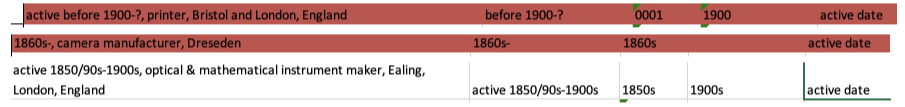

Next time:
1. Give instructions to write ’1990s’ as ’1990s’ or 1990-1999,  not just as 1990
2. Give instruction to write ‘current (2013)’ not 2013
3. Write ‘1883/4’ as 1883 in ‘from’ and 1884 in ‘to’

In [99]:
# Probably, it is better to combine two datasets - the main one and the AI one - using vectorisation. 
# But while there are relatively few entries in the AI datasets, I am using cycle

for index, bio in people_onl['BRIEF_BIO'].items():
    for i, row in additional_dates_df.iterrows():
        if bio == row['BRIEF_BIO']:

            if row['date_type'] == 'active date':
                people_onl.loc[index, 'dates'] = row['dates_ai']
                people_onl.loc[index, 'active_date_from'] = row['date_from']
                people_onl.loc[index, 'active_date_to'] = row['date_to']

                # convert dates into DateTime format
                people_onl.loc[index, 'active_date_from_dtm'] = parse_single_date(row['date_from'])

                val = row['date_to']
                if isinstance(val, str) and ('active' in val or 'current' in val):
                    people_onl.loc[index, 'active_date_to_dtm'] = pd.NaT
                else:
                    people_onl.loc[index, 'active_date_to_dtm'] = parse_single_date(val)

                people_onl.loc[index, 'Dates_from_ai'] = 1

            elif row['date_type'] == 'birth date':
                people_onl.loc[index, 'dates'] = row['dates_ai']
                people_onl.loc[index, 'birth_date_from'] = row['date_from']
                people_onl.loc[index, 'birth_date_to'] = row['date_to']

                people_onl.loc[index, 'birth_date_from_dtm'] = parse_single_date(row['date_from'])
                people_onl.loc[index, 'birth_date_to_dtm'] = parse_single_date(row['date_to'])

                people_onl.loc[index, 'Dates_from_ai'] = 1

            elif row['date_type'] == 'death date':
                people_onl.loc[index, 'dates'] = row['dates_ai']
                people_onl.loc[index, 'death_date_from'] = row['date_from']
                people_onl.loc[index, 'death_date_to'] = row['date_to']

                people_onl.loc[index, 'death_date_from_dtm'] = parse_single_date(row['date_from'])
                people_onl.loc[index, 'death_date_to_dtm'] = parse_single_date(row['date_to'])

                people_onl.loc[index, 'Dates_from_ai'] = 1

            elif row['date_type'] == 'dates of life':
                people_onl.loc[index, 'dates'] = row['dates_ai']
                people_onl.loc[index, 'unknown_date_from'] = row['date_from']
                people_onl.loc[index, 'unknown_date_to'] = row['date_to']

                people_onl.loc[index, 'unknown_date_from_dtm'] = parse_single_date(row['date_from'])
                
                val = row['date_to']
                if isinstance(val, str) and ('active' in val or 'current' in val):
                    people_onl.loc[index, 'unknown_date_to_dtm'] = pd.NaT
                else:
                    people_onl.loc[index, 'unknown_date_to_dtm'] = parse_single_date(val)

                people_onl.loc[index, 'Dates_from_ai'] = 1

NameError: name 'additional_dates_df' is not defined

### 2.3 Unifying dates

In [ ]:
# Now we have a set of dates, we need to de-duplicate them

people_onl.loc[(people_onl['unknown_date_to'] == ''), 'unknown_date_to'] = pd.NaT

people_onl['BIRTH_DATE_dtm'] = convert_to_python_dates(people_onl['BIRTH_DATE_updated'])
people_onl['DEATH_DATE_dtm'] = convert_to_python_dates(people_onl['DEATH_DATE_updated'])

# Sometimes, active and unknown dates were duplicated. Here, I delete this duplication

for i, row in people_onl.iterrows():
    date1 = row['unknown_date_from']
    date2 = row['active_date_from']
    date3 = row['unknown_date_to']
    date4 = row['active_date_to']

    if pd.notna(date1) and pd.notna(date2) and pd.notna(date3) and pd.notna(date4):  # skip missing
        if date1 == date2 and date3 == date4:
            people_onl.loc[i, 'unknown_date_from'] = pd.NaT
            people_onl.loc[i, 'unknown_date_to'] = pd.NaT

    if pd.notna(date1) and pd.notna(date2):
        if date1 == date2:
            people_onl.loc[i, 'unknown_date_from'] = pd.NaT
            people_onl.loc[i, 'unknown_date_to'] = pd.NaT

# In some cases, 'unknown dates' are in fact life dates. When it is obvious, it is better to delete this data from 'unknown date'

for i, row in people_onl.iterrows():
    date1 = row['unknown_date_from_dtm']
    date2 = row['BIRTH_DATE_dtm']
    date3 = row['unknown_date_to_dtm']
    date4 = row['DEATH_DATE_dtm']

    if pd.notna(date1) and pd.notna(date2) and pd.notna(date3) and pd.notna(date4):  # skip missing
        if date1.year == date2.year and date3.year == date4.year:
            people_onl.loc[i, 'unknown_date_from'] = pd.NaT
            people_onl.loc[i, 'unknown_date_to'] = pd.NaT
            people_onl.loc[i, 'unknown_date_from_dtm'] = pd.NaT
            people_onl.loc[i, 'unknown_date_to_dtm'] = pd.NaT
    if pd.notna(date1) and pd.notna(date2) and pd.notna(date3): 
        if date1.year == date2.year and pd.isna(date4):
            people_onl.loc[i, 'unknown_date_from'] = pd.NaT
            people_onl.loc[i, 'unknown_date_to'] = pd.NaT
            people_onl.loc[i, 'unknown_date_from_dtm'] = pd.NaT
            people_onl.loc[i, 'unknown_date_to_dtm'] = pd.NaT

people_onl.loc[(~ people_onl['unknown_date_from'].isna()) & (people_onl['BRIEF_BIO'].str.contains('current')), 'unknown_date_to'] = pd.NaT
people_onl.loc[(~ people_onl['unknown_date_from'].isna()) & (people_onl['BRIEF_BIO'].str.contains('current')), 'unknown_date_to_dtm'] = pd.NaT

In [ ]:
# Creating periods

bins = list(range(1500, 2100, 50))  # [1650, 1700, 1750, ..., 2000]
labels = [f"{start}-{start+49}" for start in bins[:-1]]  # One fewer label than bins

people_onl['active_date_from_dtm'] = pd.to_datetime(
    people_onl['active_date_from_dtm'], errors='coerce'
)

# Assign each year to a period
people_onl['Activity_starting_period'] = pd.cut(people_onl['active_date_from_dtm'].dt.year, 
                             bins=bins, 
                             labels=labels, 
                             include_lowest=True,
                             right=False)

# Count occurrences in each period
period_counts_people = people_onl['Activity_starting_period'][people_onl['@datatype.actual'] == 'person'].value_counts().sort_index()
period_counts_companies = people_onl['Activity_starting_period'][people_onl['@datatype.actual'] == 'organisation'].value_counts().sort_index()


datasets = {
    "people_onl": period_counts_people,
    "companies_onl": period_counts_companies,
}

periods_table = []

for name, data in datasets.items():
    df = pd.DataFrame(data)
    df = df.rename(columns={df.columns[0]: name})
    periods_table.append(df)

periods_table_fin = pd.concat(periods_table, axis=1, join="outer")

print(periods_table_fin)

While the differences for people are not so substantial, 'activity dates' for companies are slightly different from 'birth dates'. Is it possible that those who added info about companies in Mimsy didn't want to fill in 'birthdates' as it sounds unnatural? Or can we find any logic in these differences? 
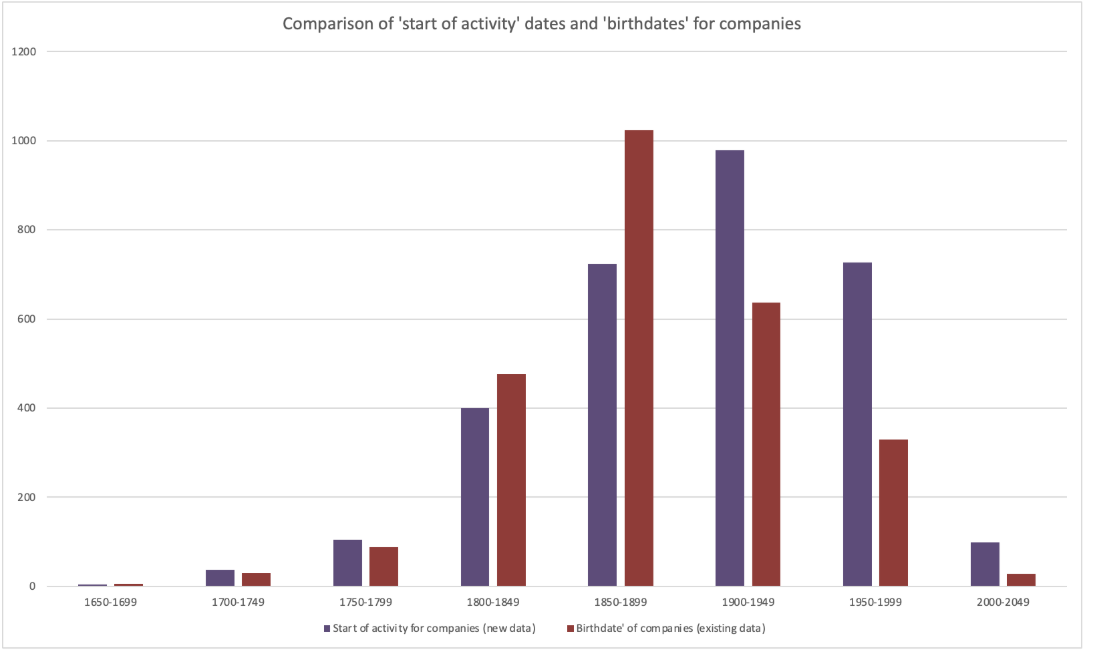

## Part 3. What 'companies' are in the People and Companies dataset? AI classification

In [103]:
# Of 7186 entries marked as non-individuals, we are choosing a random sample of 718 entries = 10%
companies_for_ai_classification = people_onl[['name[0].value', 'description[0].value']][people_onl['@datatype.actual'] == 'organisation'].sample(718)

In [ ]:
from google import genai
from pydantic import BaseModel

client = genai.Client(api_key="INSERT_YOUR_KEY")

class Class_extract(BaseModel):
    class_number: float

classes_of_companies = []

for index, row in companies_for_ai_classification.iterrows():
    name = row['name[0].value']
    bio = row['description[0].value']
    
    response = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=f""" Acting as an archivist in a museum, classify each of the entities in the museum database into one of the 10 categories:
        '1': 'manufacturers'
        '2': 'publishers'
        '3': 'transport companies (railway companies, railway lines)'
        '4': 'other companies'
        '5': 'institutions (museum, governmental body, hospital, society)'
        '6': 'ships (vessels, ships)'
        '7': 'peoples' (indigenous people)
        '8': 'person'
        '9': 'deities (gods, goddesses, saints)'
        '10': 'neither of those'
        Return the number of the category only.
        Name of the entity: {name}, description: {bio}. """,
        config={
            "response_mime_type": "application/json",
            "response_schema": list[Class_extract],
        },
    )

    data = json.loads(response.text)  # data will be a list
    
    class_number = data[0]['class_number']
    classes_of_companies.append([index, class_number])

    time.sleep(12)

In [ ]:
classes_of_companies = pd.DataFrame(classes_of_companies)
classes_of_companies.columns = ['index', 'Num']

# returning lables to classes of companies
link_to_class_type = {'1': 'manufacturers',
'2': 'publishers',
'3': 'transport companies',
'4': 'other companies',
'5': 'institutions',
'6': 'vessels',
'7': 'peoples',
'8': 'individuals',
'9': 'deities',
'10': 'neither of those'}

link_to_class_type = pd.DataFrame(
    list(link_to_class_type.items()), 
    columns=['Num', 'Class']
)
link_to_class_type['Num'] = link_to_class_type['Num'].astype(float)

classes_of_companies = classes_of_companies.merge(link_to_class_type, on='Num', how="left")

companies_classification = companies_for_ai_classification.merge(classes_of_companies, left_index=True, right_on='index')

companies_classification['Class'].value_counts()

In [ ]:
# Complex questions: for example, Curt Friedel - is he an individual who made this cash register, or is it the name of the company?
# https://collection.sciencemuseumgroup.org.uk/objects/co64426/wooden-cash-register-by-curt-friedel-germany

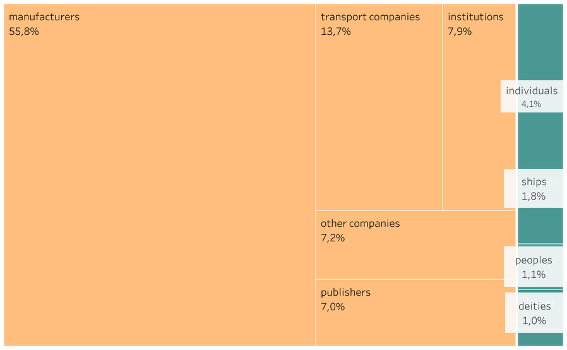